In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
from keras.utils import to_categorical
from tqdm import tqdm

In [ ]:
# 设置工作目录和文件夹列表
work_dir = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/pics'
folders = ['AK', 'AL', 'GK', 'GL', 'K', 'L', 'MK', 'ML', 'negative']

In [ ]:
#设定工作目录
import os

def count_files_in_folders(directory):
    if not os.path.isdir(directory):
        print(f"Error: '{directory}' is not a valid directory.")
        return

    folders = [f for f in os.listdir(directory) if os.path.isdir(os.path.join(directory, f))]

    for folder in folders:
        folder_path = os.path.join(directory, folder)
        num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        print(f"Folder '{folder}' has {num_files} file(s).")

# 调用函数进行扫描并输出文件数量
count_files_in_folders(work_dir)


Folder 'negative' has 4896 file(s).
Folder 'GL' has 469 file(s).
Folder 'GK' has 853 file(s).
Folder 'K' has 77 file(s).
Folder 'MK' has 108 file(s).
Folder 'L' has 91 file(s).
Folder 'AL' has 207 file(s).
Folder 'ML' has 25 file(s).
Folder 'AK' has 98 file(s).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
from PIL import Image

def random_image_size(folder_path):
    # 获取文件夹中的所有文件名
    file_names = os.listdir(folder_path)

    # 随机选择一个文件名
    random_file_name = random.choice(file_names)

    # 拼接文件的完整路径
    image_path = os.path.join(folder_path, random_file_name)

    # 使用PIL库打开图像
    image = Image.open(image_path)

    # 获取图像的尺寸
    image_size = image.size

    return image_size

# 设置工作目录和文件夹列表
work_dir = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/pics'
folders = ['AK', 'AL', 'GK', 'GL', 'K', 'L', 'MK', 'ML', 'negative']

# 随机选择一个文件夹
random_folder = random.choice(folders)

# 获取文件夹的完整路径
folder_path = os.path.join(work_dir, random_folder)

# 获取随机图像的尺寸
random_image_size = random_image_size(folder_path)

print(f"随机选择的图像尺寸为：{random_image_size}")


随机选择的图像尺寸为：(1400, 200)


将图片缩小为40×280

In [ ]:
from PIL import Image
import os

# 设置工作目录和文件夹列表
work_dir = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/pics'
output_dir = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/40_280_pics'
folders = ['AK', 'AL', 'GK', 'GL', 'K', 'L', 'MK', 'ML', 'negative']

# 设置缩小后的尺寸
new_width, new_height = 280, 40

# 循环处理每个文件夹下的图片
for folder in folders:
    folder_path = os.path.join(work_dir, folder)
    output_folder_path = os.path.join(output_dir, folder)

    # 创建输出子文件夹（如果不存在）
    os.makedirs(output_folder_path, exist_ok=True)

    files = os.listdir(folder_path)

    for file_name in files:
        # 图片原始路径
        img_path = os.path.join(folder_path, file_name)

        # 打开图片
        img = Image.open(img_path)

        # 缩小图片尺寸
        resized_img = img.resize((new_width, new_height))

        # 保存缩小后的图片
        new_file_name = "resized_" + file_name
        new_img_path = os.path.join(output_folder_path, new_file_name)
        resized_img.save(new_img_path)


KeyboardInterrupt: ignored

为了实现将 'negative' 子文件夹中的图片随机删除，最终保留1000张图片的需求，我们可以使用Python的随机数模块来实现。首先，我们需要对 'negative' 子文件夹中的文件进行随机打乱，然后删除多余的图片，只保留1000张。

In [ ]:
import os
import random

# 设置目录路径
directory = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/40_280_pics/'

# 需要保留的 'negative' 子文件夹中的图片数量
desired_count = 500

# 'negative' 子文件夹的路径
negative_folder_path = os.path.join(directory, 'negative')

# 获取 'negative' 子文件夹中的所有图片文件名
negative_files = os.listdir(negative_folder_path)

# 打乱图片文件名的顺序
random.shuffle(negative_files)

# 删除超过 desired_count 的图片
files_to_delete = negative_files[desired_count:]
for file_name in files_to_delete:
    file_path = os.path.join(negative_folder_path, file_name)
    os.remove(file_path)

print(f"已删除 'negative' 子文件夹中的 {len(files_to_delete)} 张图片，保留 {desired_count} 张图片。")


已删除 'negative' 子文件夹中的 0 张图片，保留 500 张图片。


In [ ]:
# 设置目录路径
directory = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/40_280_pics/'

# 需要保留的 'negative' 子文件夹中的图片数量
desired_count = 500

# 'negative' 子文件夹的路径
negative_folder_path = os.path.join(directory, 'GK')

# 获取 'negative' 子文件夹中的所有图片文件名
negative_files = os.listdir(negative_folder_path)

# 打乱图片文件名的顺序
random.shuffle(negative_files)

# 删除超过 desired_count 的图片
files_to_delete = negative_files[desired_count:]
for file_name in files_to_delete:
    file_path = os.path.join(negative_folder_path, file_name)
    os.remove(file_path)

print(f"已删除 'negative' 子文件夹中的 {len(files_to_delete)} 张图片，保留 {desired_count} 张图片。")

已删除 'negative' 子文件夹中的 363 张图片，保留 500 张图片。


In [ ]:
from PIL import Image
import os

def augment_image(image):
    # 创建一个图像列表来保存所有的增强图像
    images = []

    # 旋转图像
    for angle in range(-2, 2):
        images.append(image.rotate(angle))

    # 左右翻转
    images.append(image.transpose(Image.FLIP_LEFT_RIGHT))

    # 上下翻转
    images.append(image.transpose(Image.FLIP_TOP_BOTTOM))

    return images

def enhance_folder(folder_path, target_num_images):
    # 获取原始图像文件路径列表
    img_paths = [os.path.join(folder_path, img_name) for img_name in os.listdir(folder_path) if img_name.endswith('.png') or img_name.endswith('.jpg')]

    # 对每个图像进行增强
    for img_path in img_paths:
        img = Image.open(img_path)
        aug_imgs = augment_image(img)

        # 保存增强后的图像
        for i, aug_img in enumerate(aug_imgs):
            save_path = os.path.join(folder_path, f"{os.path.splitext(os.path.basename(img_path))[0]}_aug_{i}.png")
            aug_img.save(save_path)

        # 如果已经达到目标图像数量，则停止增强
        if len(os.listdir(folder_path)) >= target_num_images:
            break

# 设定工作目录
work_directory = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/40_280_pics/'

# 定义目标图像数量
target_num_images_per_folder = 500

# 获取训练集子文件夹
train_folders = [f for f in os.listdir(work_directory) if os.path.isdir(os.path.join(work_directory, f))]

# 对每个训练集文件夹进行图像增强
for folder in train_folders:
    folder_path = os.path.join(work_directory, folder)
    enhance_folder(folder_path, target_num_images_per_folder)

    print(f"Folder '{folder}' has been enhanced")

count_files_in_folders(work_directory)

Folder 'AK' has been enhanced
Folder 'AL' has been enhanced
Folder 'GK' has been enhanced
Folder 'GL' has been enhanced
Folder 'K' has been enhanced
Folder 'L' has been enhanced
Folder 'MK' has been enhanced
Folder 'ML' has been enhanced
Folder 'negative' has been enhanced
Folder 'AK' has 500 file(s).
Folder 'AL' has 501 file(s).
Folder 'GK' has 501 file(s).
Folder 'GL' has 505 file(s).
Folder 'K' has 503 file(s).
Folder 'L' has 505 file(s).
Folder 'MK' has 504 file(s).
Folder 'ML' has 505 file(s).
Folder 'negative' has 500 file(s).


In [2]:
from PIL import Image
import os
import numpy as np

# 设置工作目录和文件夹列表
work_dir = '/content/drive/MyDrive/Colab Notebooks/202306/Immunofixation electrophoresis/40_280_pics'
folders = ['AK', 'AL', 'GK', 'GL', 'K', 'L', 'MK', 'ML', 'negative']

# 初始化空列表，用于存储图像数据和标签
X = []
y = []

# 遍历文件夹列表
for label, folder in enumerate(folders):
    folder_path = os.path.join(work_dir, folder)
    file_names = os.listdir(folder_path)

    # 分段处理数据
    chunk_size = 100  # 每次处理的图像数量
    num_chunks = len(file_names) // chunk_size  # 分段数目
    remainder = len(file_names) % chunk_size  # 剩余的图像数量

    for chunk in tqdm(range(num_chunks), desc=f"Processing {folder} folder"):
        start = chunk * chunk_size
        end = (chunk + 1) * chunk_size

        # 遍历文件名列表的当前分段
        for file_name in file_names[start:end]:
            image_path = os.path.join(folder_path, file_name)

            # 加载灰度图像并转换为RGB图像
            gray_image = Image.open(image_path).convert('L')
            rgb_image = gray_image.convert('RGB')

            # 调整图像大小为所需尺寸
            rgb_image = rgb_image.resize((280, 40))

            # 将图像转换为数组并进行预处理
            x = np.array(rgb_image)
            x = preprocess_input(x)

            # 将数据和标签添加到列表中
            X.append(x)
            y.append(label)

    # 处理剩余的图像
    for file_name in tqdm(file_names[-remainder:], desc=f"Processing remaining {folder} images"):
        image_path = os.path.join(folder_path, file_name)

        # 加载灰度图像并转换为RGB图像
        gray_image = Image.open(image_path).convert('L')
        rgb_image = gray_image.convert('RGB')

        # 调整图像大小为所需尺寸
        rgb_image = rgb_image.resize((280, 40))

        # 将图像转换为数组并进行预处理
        x = np.array(rgb_image)
        x = preprocess_input(x)

        # 将数据和标签添加到列表中
        X.append(x)
        y.append(label)

# 将数据和标签转换为数组
X = np.array(X)
y = np.array(y)


Processing remaining negative images: 100%|██████████| 500/500 [00:00<00:00, 658.94it/s]


In [3]:
print(X.shape)
print(y.shape)

(5523, 40, 280, 3)
(5523,)


In [4]:
# 对图像数据进行归一化（可选）
X = X / 255.0

# 将标签转换为独热编码
y = to_categorical(y, num_classes=len(folders))

In [5]:
# 划分训练集和测试集（可根据需要进行调整）
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)


In [6]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [7]:
from keras.utils import to_categorical
import cv2

# 将灰度图像转换为伪彩色图像
def gray_to_pseudo_color(gray_image):
    gray_image_uint8 = (gray_image * 255).astype(np.uint8)
    pseudo_color_image = cv2.applyColorMap(cv2.cvtColor(gray_image_uint8, cv2.COLOR_GRAY2BGR), cv2.COLORMAP_JET)
    return pseudo_color_image

# 将灰度图像数据转换为3通道伪彩色图像数据
X_train_rgb = np.array([gray_to_pseudo_color(img) for img in X_train])
X_test_rgb = np.array([gray_to_pseudo_color(img) for img in X_test])

# 确保像素值在 [0, 1] 范围内
X_train_rgb = X_train_rgb / 255.0
X_test_rgb = X_test_rgb / 255.0

# 将标签转换为独热编码
y_train_categorical = to_categorical(y_train, num_classes=len(folders))
y_test_categorical = to_categorical(y_test, num_classes=len(folders))

# 构建模型
input_shape = (40, 280, 3)
# ...


In [25]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)


# 添加全局平均池化层和全连接层
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(len(folders), activation='softmax')(x)

# 创建新的模型
model = Model(inputs=base_model.input, outputs=predictions)


# 编译模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 输出模型结构
model.summary()


29084464/29084464 [==============================] - 0s 0us/step
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 40, 280, 3)  0           []                               
                                ]                                                                 
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 46, 286, 3)  0           ['input_4[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 20, 140, 64)  9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalizati

In [26]:
# 训练模型
epochs = 200
batch_size = 32
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))


Epoch 1/200
121/121 [==============================] - 104s 219ms/step - loss: 1.7092 - accuracy: 0.3991 - val_loss: 4.6230 - val_accuracy: 0.1279
Epoch 2/200
121/121 [==============================] - 14s 120ms/step - loss: 1.0827 - accuracy: 0.6469 - val_loss: 1.5940 - val_accuracy: 0.6095
Epoch 3/200
121/121 [==============================] - 16s 130ms/step - loss: 0.7376 - accuracy: 0.7646 - val_loss: 3.3253 - val_accuracy: 0.3989
Epoch 4/200
121/121 [==============================] - 14s 119ms/step - loss: 0.6162 - accuracy: 0.8016 - val_loss: 11.4740 - val_accuracy: 0.1352
Epoch 5/200
121/121 [==============================] - 16s 129ms/step - loss: 0.5094 - accuracy: 0.8376 - val_loss: 0.8807 - val_accuracy: 0.7568
Epoch 6/200
121/121 [==============================] - 14s 119ms/step - loss: 0.4500 - accuracy: 0.8520 - val_loss: 2.2135 - val_accuracy: 0.4502
Epoch 7/200
121/121 [==============================] - 16s 129ms/step - loss: 0.4114 - accuracy: 0.8689 - val_loss: 1.2495

Best Epoch:  119
Training Accuracy at Best Epoch:  0.964045524597168
Validation Accuracy at Best Epoch:  0.9269764423370361


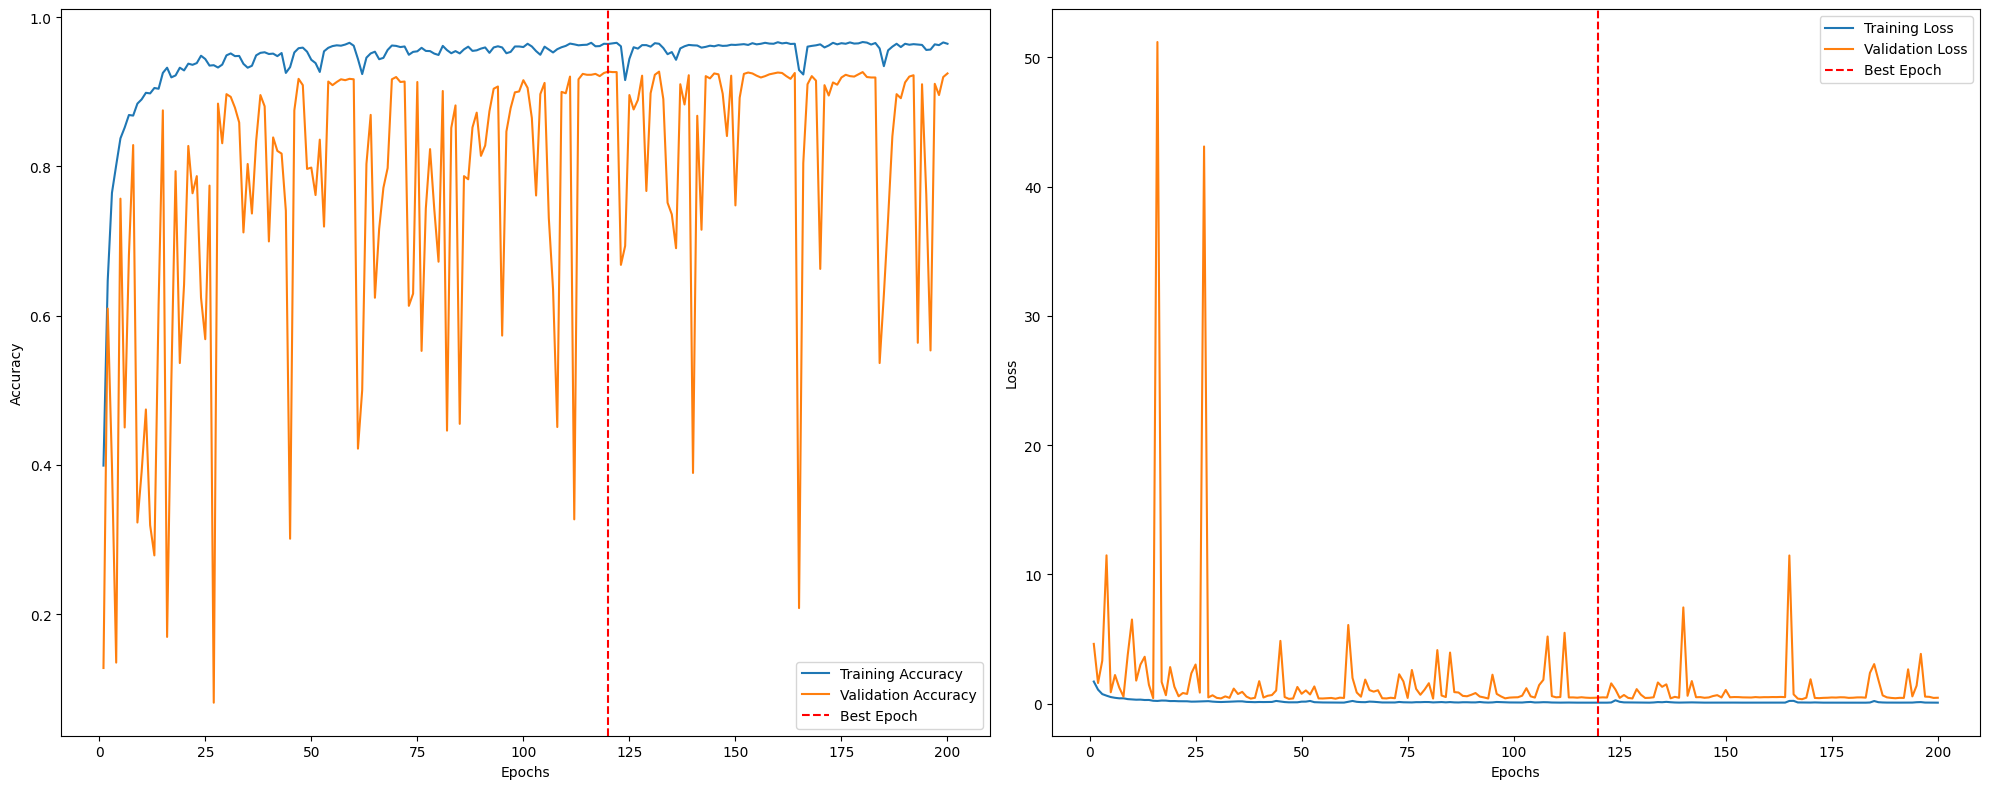

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils.vis_utils import plot_model

# 假设你已经训练了模型并保存了训练过程的历史记录在 history 变量中
# 获取训练集和验证集上的准确率历史记录
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# 找到验证集上准确率最高的一次迭代的索引
best_epoch = np.argmax(val_accuracy)

# 输出最佳迭代次数时的训练集和验证集准确率
print("Best Epoch: ", best_epoch)
print("Training Accuracy at Best Epoch: ", train_accuracy[best_epoch])
print("Validation Accuracy at Best Epoch: ", val_accuracy[best_epoch])

# 绘制训练曲线
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_accuracy, label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracy, label='Validation Accuracy')
plt.axvline(x=best_epoch + 1, color='red', linestyle='--', label='Best Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 绘制损失曲线（如果有的话）
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_loss, label='Training Loss')
plt.plot(range(1, epochs + 1), val_loss, label='Validation Loss')
plt.axvline(x=best_epoch + 1, color='red', linestyle='--', label='Best Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 根据最佳迭代的索引获取最佳的模型参数
best_model_params = model.get_weights()

# 将模型参数设置为最佳迭代的参数
model.set_weights(best_model_params)

# 重新编译模型（因为之前的模型编译可能包含优化器的状态等）
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
import pickle

# 假设 `history` 是你训练模型后得到的 History 对象
# history = model.fit(...)

# 保存 History 对象
with open('history0830_DenseNet_0.926.pkl', 'wb') as f:
    pickle.dump(history.history, f)


52/52 [==============================] - 4s 25ms/step


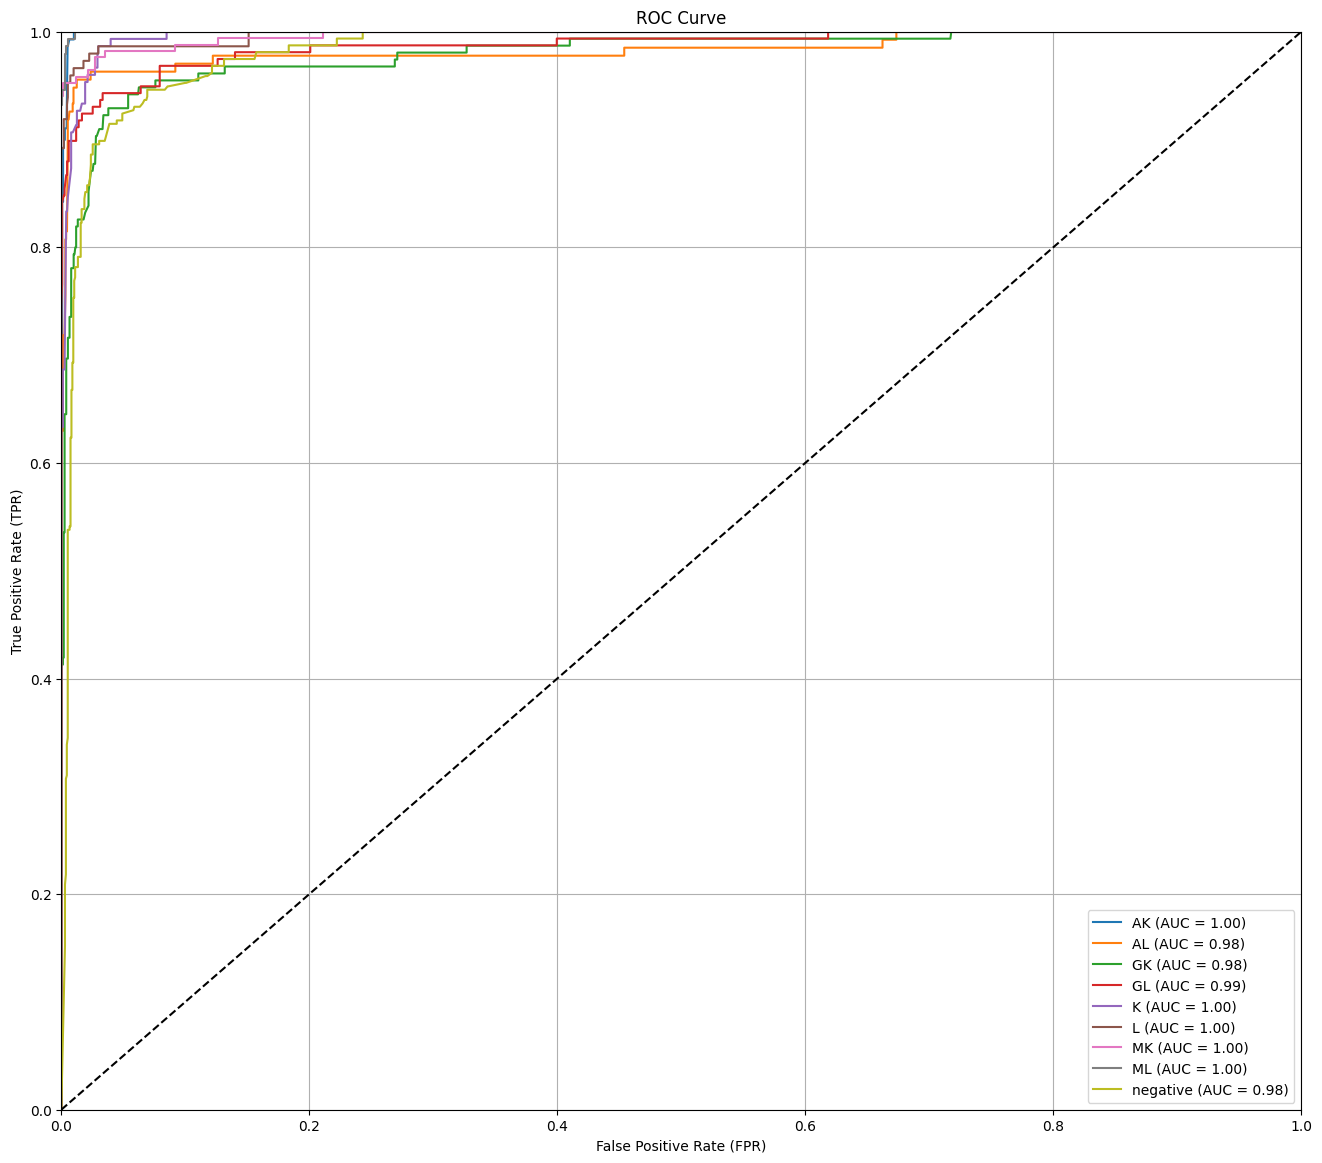

In [30]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

# 假设模型已经训练并保存为 model 变量，并且 X_test 和 y_test 是验证集的特征和标签数据

# 进行预测
y_pred = model.predict(X_test)

# 计算ROC曲线
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(folders)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制ROC曲线
plt.figure(figsize=(16, 14))
for i in range(len(folders)):
    plt.plot(fpr[i], tpr[i], label=f'{folders[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [29]:

model.save('my_model_0830DenseNet(val_0.926).h5')


In [15]:
from keras.models import load_model

# 以下代码将加载 'my_model.h5' 文件中的模型
loaded_model = load_model('my_model_0830ResNet.h5')


OSError: ignored